# 03 — Model Training
### AI-Powered Resume Screening & Candidate Role Recommendation
---
**Run 02_Preprocessing_Feature_Engineering.ipynb first.**
This notebook trains Logistic Regression, Random Forest, SVM, and XGBoost, runs hyperparameter tuning and cross-validation, and saves all trained pipelines to `models/`.


In [1]:
import os, ast, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import randint, uniform

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV, cross_val_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded.")


Libraries loaded.


## 1. Load Data & Preprocessor

In [2]:
train_df = pd.read_csv('data/train_df.csv')
test_df  = pd.read_csv('data/test_df.csv')
y_train  = np.load('data/y_train.npy')
y_test   = np.load('data/y_test.npy')

# Re-parse extracted_skills
for df in [train_df, test_df]:
    df['extracted_skills'] = df['extracted_skills'].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

print(f"Train: {train_df.shape}, Test: {test_df.shape}")
print(f"Classes: {len(np.unique(y_train))}")


Train: (8000, 14), Test: (2000, 14)
Classes: 42


In [3]:
# Rebuild preprocessor (same config as notebook 02)
text_col     = 'clean_text'
numeric_cols = ['Experience Years', 'skill_count', 'education_level']

preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(max_features=3000), text_col),
        ('num',   StandardScaler(),                  numeric_cols)
    ]
)
print("Preprocessor ready.")


Preprocessor ready.


## 2. Why These Algorithms?

- **Logistic Regression** — strong linear baseline for high-dimensional sparse TF-IDF data; fast and interpretable.
- **Random Forest** — captures non-linear feature interactions; native feature importances.
- **Linear SVM** — classically best-in-class for sparse high-dimensional text; data tends to be linearly separable in TF-IDF space.
- **XGBoost** — gradient boosting handles the 42-class imbalance and non-linearities well; contrasts with RF's bagging approach.
- **K-Means** (Notebook 04) — centroid-based method fits globular clusters formed after TF-IDF + SVD dimensionality reduction.

## 3. Train All Models

In [4]:
def evaluate(name, y_true, y_pred):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted'), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, average='weighted'), 4)
    }


### 3.1 Logistic Regression

In [5]:
lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=1.0))
])
lr_pipe.fit(train_df, y_train)
y_pred_lr = lr_pipe.predict(test_df)

res_lr = evaluate('Logistic Regression', y_test, y_pred_lr)
print(res_lr)


{'Model': 'Logistic Regression', 'Accuracy': 0.9805, 'Precision': 0.9811, 'Recall': 0.9805, 'F1-Score': 0.9804}


### 3.2 Random Forest

In [6]:
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
])
rf_pipe.fit(train_df, y_train)
y_pred_rf = rf_pipe.predict(test_df)

res_rf = evaluate('Random Forest', y_test, y_pred_rf)
print(res_rf)


{'Model': 'Random Forest', 'Accuracy': 0.9855, 'Precision': 0.9859, 'Recall': 0.9855, 'F1-Score': 0.9853}


### 3.3 Support Vector Machine

In [7]:
svc_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=RANDOM_STATE)))
])
svc_pipe.fit(train_df, y_train)
y_pred_svc = svc_pipe.predict(test_df)

res_svc = evaluate('SVM', y_test, y_pred_svc)
print(res_svc)


{'Model': 'SVM', 'Accuracy': 0.9905, 'Precision': 0.9907, 'Recall': 0.9905, 'F1-Score': 0.9904}


### 3.4 XGBoost

In [8]:
xgb_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, gamma=0.1,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist'
    ))
])
xgb_pipe.fit(train_df, y_train)
y_pred_xgb = xgb_pipe.predict(test_df)

res_xgb = evaluate('XGBoost', y_test, y_pred_xgb)
print(res_xgb)


{'Model': 'XGBoost', 'Accuracy': 0.968, 'Precision': 0.9688, 'Recall': 0.968, 'F1-Score': 0.9678}


## 4. Model Comparison

              Model  Accuracy  Precision  Recall  F1-Score
                SVM    0.9905     0.9907  0.9905    0.9904
      Random Forest    0.9855     0.9859  0.9855    0.9853
Logistic Regression    0.9805     0.9811  0.9805    0.9804
            XGBoost    0.9680     0.9688  0.9680    0.9678


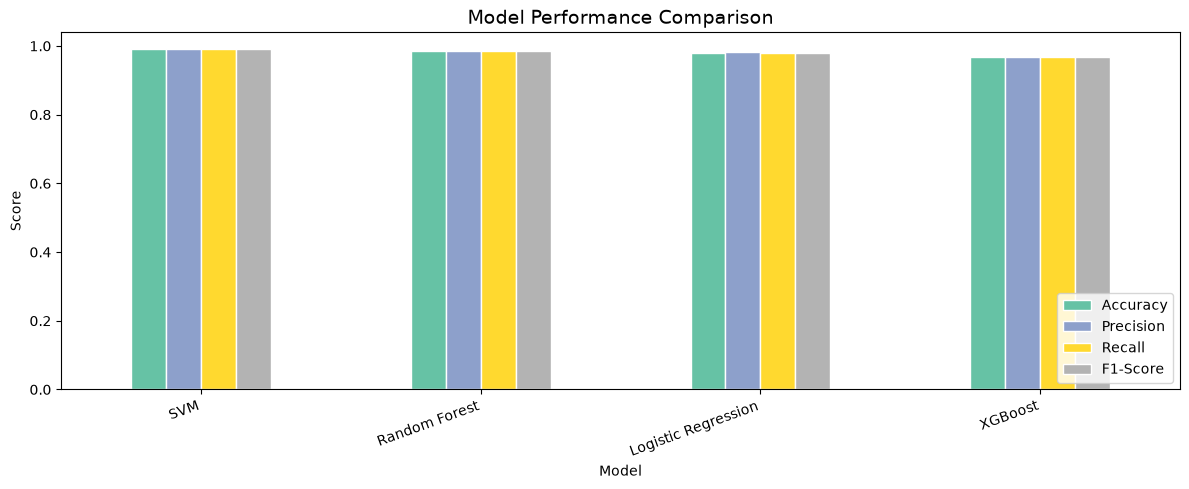


Best model: SVM


In [9]:
comparison_df = (pd.DataFrame([res_lr, res_rf, res_svc, res_xgb])
                 .sort_values('F1-Score', ascending=False)
                 .reset_index(drop=True))
print(comparison_df.to_string(index=False))

comparison_df.set_index('Model')[['Accuracy','Precision','Recall','F1-Score']].plot(
    kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='white')
plt.title('Model Performance Comparison', fontsize=14)
plt.ylabel('Score'); plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right'); plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150); plt.show()

best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest model: {best_model_name}")


## 5. Hyperparameter Tuning — GridSearchCV (Random Forest)
`GridSearchCV` runs on the **full pipeline** so each CV fold refits its own TF-IDF — no leakage.

In [10]:
param_grid = {
    'clf__n_estimators'      : [100, 200],
    'clf__max_depth'         : [None, 20, 30],
    'clf__min_samples_split' : [2, 5]
}

rf_grid_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

grid_search = GridSearchCV(
    rf_grid_pipe, param_grid, cv=5,
    scoring='f1_weighted', n_jobs=-1, verbose=1
)
grid_search.fit(train_df, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1 :", round(grid_search.best_score_, 4))


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Best CV F1 : 0.9886


In [11]:
tuned_rf_pipe = grid_search.best_estimator_
y_pred_tuned_rf = tuned_rf_pipe.predict(test_df)
print("Tuned RF — Accuracy:", round(accuracy_score(y_test, y_pred_tuned_rf), 4))
print("Tuned RF — F1-Score:", round(f1_score(y_test, y_pred_tuned_rf, average='weighted'), 4))


Tuned RF — Accuracy: 0.9825
Tuned RF — F1-Score: 0.9823


## 5.5 Regularization — L1 vs L2 (Logistic Regression)
The course CEP brief explicitly requires regularization as part of Phase 4.
Logistic Regression supports both L1 (Lasso) and L2 (Ridge) penalties:
- **L1 (Lasso)** — drives some coefficients to exactly zero → sparse model, built-in feature selection.
- **L2 (Ridge)** — shrinks all coefficients but keeps them non-zero → better when all features contribute.
- **C parameter** controls regularization strength: smaller C = stronger regularization.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

reg_results = []

for penalty in ['l1', 'l2']:
    for C in [0.01, 0.1, 1.0, 10.0]:
        pipe = Pipeline([
            ('prep', preprocessor),
            ('clf', LogisticRegression(
                penalty=penalty, C=C,
                solver='saga',        # saga supports both L1 and L2
                max_iter=1000,
                random_state=RANDOM_STATE
            ))
        ])
        pipe.fit(train_df, y_train)
        preds = pipe.predict(test_df)
        reg_results.append({
            'Penalty': penalty.upper(),
            'C': C,
            'F1-Score': round(f1_score(y_test, preds, average='weighted'), 4)
        })

reg_df = pd.DataFrame(reg_results)
print(reg_df.to_string(index=False))

Penalty     C  F1-Score
     L1  0.01    0.1069
     L1  0.10    0.7181
     L1  1.00    0.9729
     L1 10.00    0.9839
     L2  0.01    0.1509
     L2  0.10    0.7223
     L2  1.00    0.9804
     L2 10.00    0.9879


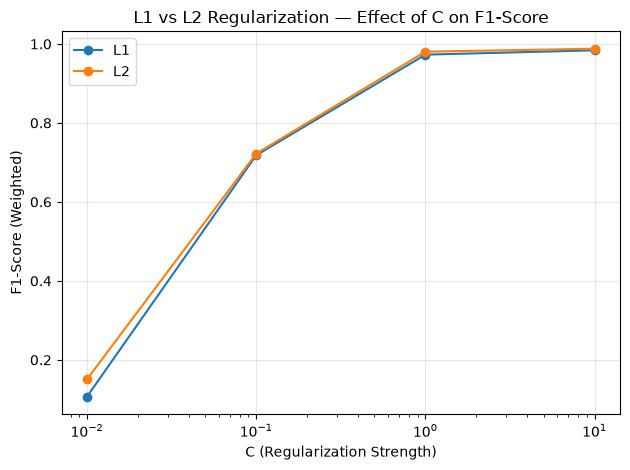


Best config: Penalty=L2, C=10.0, F1=0.9879


In [13]:
import matplotlib.pyplot as plt

for penalty in ['L1', 'L2']:
    subset = reg_df[reg_df['Penalty'] == penalty]
    plt.plot(subset['C'], subset['F1-Score'], marker='o', label=penalty)

plt.xscale('log')
plt.xlabel('C (Regularization Strength)')
plt.ylabel('F1-Score (Weighted)')
plt.title('L1 vs L2 Regularization — Effect of C on F1-Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/regularization_comparison.png', dpi=150)
plt.show()

best_reg = reg_df.loc[reg_df['F1-Score'].idxmax()]
print(f"\nBest config: Penalty={best_reg['Penalty']}, C={best_reg['C']}, F1={best_reg['F1-Score']}")

## 6. Hyperparameter Tuning — RandomizedSearchCV (XGBoost)
Randomized Search covers a continuous hyperparameter space more efficiently than grid search. Applied to XGBoost to demonstrate both tuning techniques on different models (per course brief).

In [ ]:
param_dist = {
    'clf__n_estimators'    : randint(80, 250),
    'clf__max_depth'       : randint(3, 9),
    'clf__learning_rate'   : uniform(0.03, 0.27),
    'clf__subsample'       : uniform(0.6, 0.4),
    'clf__colsample_bytree': uniform(0.6, 0.4),
    'clf__min_child_weight': randint(1, 7),
    'clf__gamma'           : uniform(0, 0.5)
}

xgb_random_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', XGBClassifier(
        eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist'
    ))
])

random_search = RandomizedSearchCV(
    xgb_random_pipe, param_distributions=param_dist,
    n_iter=20, cv=3,
    scoring='f1_weighted', random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
random_search.fit(train_df, y_train) 

print("Best params:", random_search.best_params_)
print("Best CV F1 :", round(random_search.best_score_, 4))


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'clf__colsample_bytree': np.float64(0.9160702162124823), 'clf__gamma': np.float64(0.3029799873905057), 'clf__learning_rate': np.float64(0.28010123719860425), 'clf__max_depth': 4, 'clf__min_child_weight': 1, 'clf__n_estimators': 107, 'clf__subsample': np.float64(0.9452413703502374)}
Best CV F1 : 0.9627


In [15]:
tuned_xgb_pipe = random_search.best_estimator_
y_pred_tuned_xgb = tuned_xgb_pipe.predict(test_df)
print("Tuned XGBoost — Accuracy:", round(accuracy_score(y_test, y_pred_tuned_xgb), 4))
print("Tuned XGBoost — F1-Score:", round(f1_score(y_test, y_pred_tuned_xgb, average='weighted'), 4))


Tuned XGBoost — Accuracy: 0.9665
Tuned XGBoost — F1-Score: 0.9663


## 7. Cross-Validation (5-Fold)
Run on full dataset through pipeline — each fold refits its own vectorizer.

In [16]:
resume_df_full = pd.read_csv('data/processed_resume.csv')
resume_df_full['extracted_skills'] = resume_df_full['extracted_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
y_full = resume_df_full['category_encoded'].values

cv_scores = cross_val_score(
    tuned_rf_pipe, resume_df_full, y_full,
    cv=5, scoring='f1_weighted', n_jobs=-1
)

print("CV F1 Scores:", np.round(cv_scores, 4))
print(f"Mean F1     : {cv_scores.mean():.4f}")
print(f"Std Dev     : {cv_scores.std():.4f}")


CV F1 Scores: [0.9894 0.9925 0.9889 0.9889 0.9879]
Mean F1     : 0.9895
Std Dev     : 0.0016


## 8. Save All Models

In [17]:
pipelines_to_save = {
    'logistic_regression_pipeline' : lr_pipe,
    'random_forest_pipeline'       : rf_pipe,
    'svm_pipeline'                 : svc_pipe,
    'xgboost_pipeline'             : xgb_pipe,
    'random_forest_tuned_gridsearch' : tuned_rf_pipe,
    'xgboost_tuned_randomsearch'     : tuned_xgb_pipe,
}

for name, model in pipelines_to_save.items():
    joblib.dump(model, f'models/{name}.pkl')
    print(f"Saved: models/{name}.pkl")

# Also save comparison results
comparison_df.to_csv('outputs/model_comparison_results.csv', index=False)

# Save best model name and predictions for notebook 04
import json
with open('data/best_model_name.json', 'w') as f:
    json.dump({'best_model': best_model_name}, f)

print("\n✅ 03_Model_Training.ipynb complete — run 04_Evaluation_Recommendation_System.ipynb next.")


Saved: models/logistic_regression_pipeline.pkl
Saved: models/random_forest_pipeline.pkl
Saved: models/svm_pipeline.pkl
Saved: models/xgboost_pipeline.pkl
Saved: models/random_forest_tuned_gridsearch.pkl
Saved: models/xgboost_tuned_randomsearch.pkl

✅ 03_Model_Training.ipynb complete — run 04_Evaluation_Recommendation_System.ipynb next.
